In [36]:
#Importo as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [37]:
#Carrego os arquivos de dados
dfVendas = pd.read_csv("dfVendas.csv", delimiter= ",")
dfVendasExtras = pd.read_csv("dfVendasExtras.csv", delimiter= ",")

In [38]:
#Concateno as bases em uma só
dfTotalVendas = pd.concat([dfVendas, dfVendasExtras], ignore_index=True)
dfTotalVendas.head(2)

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,ID_Campanha
0,1,350,45,2022-09-23,4,Online,5795.64,17
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16


In [39]:
#Crio uma coluna com o Mês da venda
dfTotalVendas["Mês"] = dfTotalVendas["Data"].str[5:7].astype(int)
dfTotalVendas

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,ID_Campanha,Mês
0,1,350,45,2022-09-23,4,Online,5795.64,17,9
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16,2
2,3,915,75,2022-09-11,4,Online,2057.48,17,9
3,4,494,47,2024-05-10,4,Loja Física,12864.44,9,5
4,5,523,79,2023-10-15,4,Loja Física,13317.28,5,10
...,...,...,...,...,...,...,...,...,...
23995,23996,99,68,2024-11-06,2,Online,9228.82,10,11
23996,23997,225,90,2024-10-14,2,Loja Física,6536.63,20,10
23997,23998,974,15,2024-12-29,4,Loja Física,12565.21,6,12
23998,23999,269,44,2025-06-13,3,Loja Física,9834.99,15,6


In [40]:
#Crio uma coluna com o Ano da venda
dfTotalVendas["Ano"] = dfTotalVendas["Data"].str[0:4].astype(int)
dfTotalVendas

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,ID_Campanha,Mês,Ano
0,1,350,45,2022-09-23,4,Online,5795.64,17,9,2022
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16,2,2024
2,3,915,75,2022-09-11,4,Online,2057.48,17,9,2022
3,4,494,47,2024-05-10,4,Loja Física,12864.44,9,5,2024
4,5,523,79,2023-10-15,4,Loja Física,13317.28,5,10,2023
...,...,...,...,...,...,...,...,...,...,...
23995,23996,99,68,2024-11-06,2,Online,9228.82,10,11,2024
23996,23997,225,90,2024-10-14,2,Loja Física,6536.63,20,10,2024
23997,23998,974,15,2024-12-29,4,Loja Física,12565.21,6,12,2024
23998,23999,269,44,2025-06-13,3,Loja Física,9834.99,15,6,2025


In [41]:
#Retiro somente as informações de 2025
dfVendas2025 = dfTotalVendas.loc[dfTotalVendas["Ano"].isin([2025])]
dfVendas2025

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,ID_Campanha,Mês,Ano
20000,20001,57,56,2025-05-25,2,Loja Física,8275.01,15,5,2025
20001,20002,183,12,2025-07-12,1,Online,3160.61,15,7,2025
20003,20004,597,67,2025-08-30,4,Online,6241.74,13,8,2025
20004,20005,892,71,2025-01-14,2,Online,3870.35,6,1,2025
20006,20007,52,23,2025-09-08,4,Loja Física,18592.36,13,9,2025
...,...,...,...,...,...,...,...,...,...,...
23990,23991,611,61,2025-07-13,4,Loja Física,20848.84,15,7,2025
23991,23992,208,39,2025-07-29,3,Online,15004.85,13,7,2025
23993,23994,863,2,2025-06-07,1,Loja Física,3428.23,15,6,2025
23994,23995,617,96,2025-01-26,2,Online,856.76,6,1,2025


In [42]:
#Somo as vendas por mês
dfVendasMes2025 = dfVendas2025.groupby("Mês")["Valor_Total"].sum().reset_index()
dfVendasMes2025

,Mês,Valor_Total
0,1,2228886.62
1,2,2073643.61
2,3,2327389.97
3,4,2224591.27
4,5,2400940.63
5,6,2184694.28
6,7,2133897.68
7,8,2220941.12
8,9,2026972.71


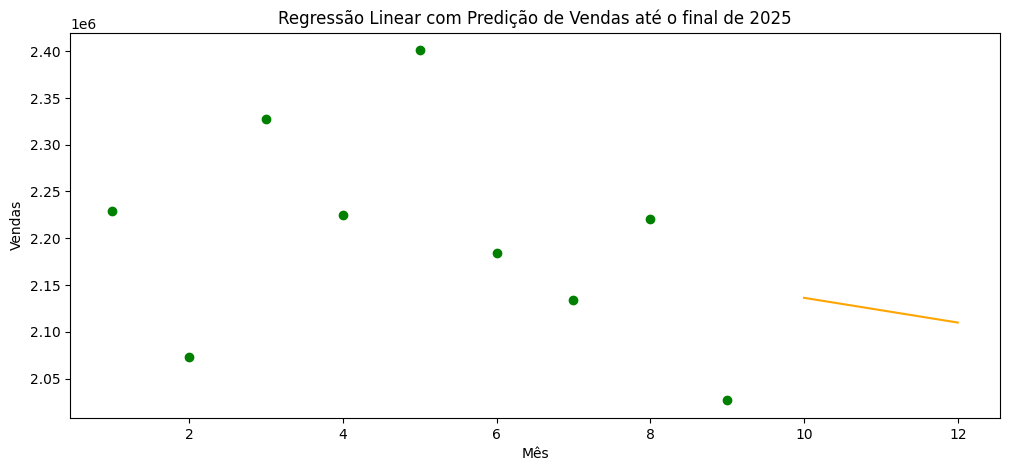

In [43]:
#Defino o x e y do modelo
x = dfVendasMes2025[["Mês"]]
y = dfVendasMes2025["Valor_Total"]

#Treinar o modelo
modelo = LinearRegression()
modelo.fit(x,y)

#Fazer a predição para as vendas até o final de 2025
x_predicao = pd.DataFrame({"Mês": [10, 11, 12]})
y_predicao = modelo.predict(x_predicao)

#Visualizar o gráfico
plt.figure(figsize=(12,5))
plt.scatter(dfVendasMes2025["Mês"], dfVendasMes2025["Valor_Total"], color='green')
plt.plot(x_predicao["Mês"], y_predicao, color='orange')
plt.xlabel("Mês")
plt.ylabel("Vendas")
plt.title("Regressão Linear com Predição de Vendas até o final de 2025")
plt.show()